<a href="https://colab.research.google.com/github/DiegoFau/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Predicción de Cancelación (Churn)**

##1. Introducción

###1.1 Contexto del problema


La cancelación de clientes (churn) representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que impacta directamente en los ingresos recurrentes y en la estabilidad del negocio. En mercados altamente competitivos, donde los clientes pueden cambiar fácilmente de proveedor, comprender los factores que impulsan la cancelación se vuelve una prioridad estratégica.

En la primera etapa de este proyecto se realizó un análisis exploratorio de datos (EDA) sobre la base de clientes de Telecom X, con el objetivo de identificar patrones asociados al abandono del servicio. Dicho análisis permitió detectar tendencias relevantes, como una mayor tasa de cancelación en clientes con contratos mensuales, menor antigüedad y mayor gasto relativo.

A partir de estos hallazgos iniciales surge la necesidad de avanzar hacia un enfoque predictivo que permita anticipar el riesgo de cancelación antes de que ocurra, facilitando la implementación de estrategias de retención más efectivas.

###1.2 Objetivo del modelado predictivo

El objetivo de esta segunda etapa del proyecto es desarrollar modelos de machine learning capaces de predecir la probabilidad de cancelación de los clientes de Telecom X.

Para lograrlo, se construirá un pipeline de análisis que permitirá:

* Preparar y transformar los datos para su uso en algoritmos de aprendizaje automático.
* Identificar variables relevantes asociadas al churn.
* Entrenar distintos modelos de clasificación.
* Evaluar su desempeño mediante métricas de rendimiento.
* Interpretar los resultados para identificar los factores que más influyen en la cancelación.

El propósito final no es únicamente obtener un modelo predictivo preciso, sino también generar insights accionables que ayuden a la empresa a diseñar estrategias de retención de clientes basadas en datos.

###1.3 Enfoque metodológico

El desarrollo de este proyecto seguirá una estructura típica de proyectos de Machine Learning aplicado, compuesta por las siguientes etapas:


1. Preparación de los datos
Se realizará la carga del dataset tratado en la etapa anterior, junto con la eliminación de variables irrelevantes, codificación de variables categóricas y verificación del balance de clases.

2. Análisis de correlación y selección de variables
Se explorarán las relaciones entre variables numéricas y la variable objetivo con el fin de identificar posibles predictores relevantes.

3. Construcción de modelos predictivos
Se entrenarán al menos dos modelos de clasificación utilizando diferentes enfoques algorítmicos, permitiendo comparar su desempeño.

4. Evaluación de modelos
Los modelos serán evaluados mediante métricas como exactitud, precisión, recall, F1-score y matriz de confusión, con el objetivo de determinar su capacidad predictiva.

5. Interpretación de resultados y conclusiones
Finalmente, se analizará la importancia de las variables en los modelos seleccionados y se elaborarán conclusiones estratégicas sobre los principales factores asociados a la cancelación de clientes.

Este enfoque permitirá no solo construir modelos predictivos robustos, sino también transformar los resultados en conocimiento útil para la toma de decisiones en Telecom X.

#2. Preparación de los Datos

## 2.1 Carga del Dataset Tratado

En esta etapa se carga el dataset previamente tratado en la Parte 1 del proyecto, el cual contiene los datos ya normalizados, con variables limpias y estructuradas para el análisis.

Este archivo corresponde a la base de datos de clientes de Telecom X e incluye información demográfica, contractual, de servicios y facturación. Además, contiene la variable objetivo Churn, que indica si el cliente canceló o no el servicio.

In [2]:
import pandas as pd

#Cargar dt tratado
df = pd.read_csv('/content/drive/MyDrive/TelecomX_parte2_Latam/datos_tratados.csv')

#Visualizar primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1


In [3]:
# Dimensiones
df.shape

(7043, 23)

In [4]:
# Informacion general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

In [5]:
# Verificacion de la variable objetivo

df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


##2.2 Eliminación de Columnas Irrelevantes

En esta etapa se eliminan variables que no aportan información útil para el entrenamiento del modelo o que pueden generar redundancia en el análisis.

Se eliminarán la columna customerID y la variable Churn, debido a que ya se creó previamente una versión numérica llamada Churn_bin, que será utilizada como variable objetivo en los modelos de clasificación. Mantener ambas variables generaría redundancia en el dataset.

In [6]:
# Eliminar costumerID
df = df.drop(columns=['customerID', 'Churn'])

# Verificar
df.columns

Index(['customer.gender', 'customer.SeniorCitizen', 'customer.Partner',
       'customer.Dependents', 'customer.tenure', 'phone.PhoneService',
       'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias',
       'Churn_bin'],
      dtype='object')

In [7]:
df.head()

,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1


In [8]:
df.shape

(7043, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer.gender            7043 non-null   object 
 1   customer.SeniorCitizen     7043 non-null   int64  
 2   customer.Partner           7043 non-null   object 
 3   customer.Dependents        7043 non-null   object 
 4   customer.tenure            7043 non-null   int64  
 5   phone.PhoneService         7043 non-null   object 
 6   phone.MultipleLines        7043 non-null   object 
 7   internet.InternetService   7043 non-null   object 
 8   internet.OnlineSecurity    7043 non-null   object 
 9   internet.OnlineBackup      7043 non-null   object 
 10  internet.DeviceProtection  7043 non-null   object 
 11  internet.TechSupport       7043 non-null   object 
 12  internet.StreamingTV       7043 non-null   object 
 13  internet.StreamingMovies   7043 non-null   objec

## 2.3 Encoding de Variables Categóricas


Antes de continuar con la preparación de los datos, es necesario revisar y tratar los valores faltantes presentes en el dataset.

De acuerdo con la inspección previa (df.info()), la variable account.Charges.Total presenta 11 valores nulos. Esta variable representa el total acumulado de cargos del cliente y es relevante para el análisis del comportamiento de cancelación.

Los valores faltantes suelen aparecer en clientes con muy poco tiempo de permanencia (tenure), ya que aún no han acumulado cargos suficientes.

Para evitar problemas en etapas posteriores del modelado, se opta por eliminar las filas con valores nulos, dado que representan una proporción muy pequeña del dataset (11 de 7043 registros) y su eliminación no afecta significativamente el análisis.


In [10]:
# Contar valores nulos por columna
df.isnull().sum()

,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0
internet.OnlineSecurity,0
internet.OnlineBackup,0


In [11]:
# Eliminar filas con valores nulos
df = df.dropna()

# Verificar nuevamente
df.isnull().sum()

,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0
internet.OnlineSecurity,0
internet.OnlineBackup,0


In [12]:
df.shape

(7032, 21)

Los modelos de machine learning requieren que todas las variables estén en formato numérico. Sin embargo, en el dataset existen múltiples variables categóricas (tipo object) que representan características como género, tipo de contrato, método de pago y servicios contratados.

Para transformar estas variables en formato numérico se utiliza One-Hot Encoding, implementado en pandas mediante la función get_dummies(). Este método crea nuevas columnas binarias (0 y 1) para cada categoría presente en las variables categóricas.

De esta forma, cada categoría se representa como una variable independiente que puede ser interpretada por los algoritmos de clasificación.

In [13]:
# Identificar variables categóricas
categoricas_col = df.select_dtypes(include="object").columns

categoricas_col

Index(['customer.gender', 'customer.Partner', 'customer.Dependents',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod'],
      dtype='object')

In [14]:
# Aplicar encoding
df_encoded = pd.get_dummies(df, columns=categoricas_col, drop_first=True)

# Visualizar primeras filas
df_encoded.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,0,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,0,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,1,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,1,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,1,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [15]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   customer.SeniorCitizen                         7032 non-null   int64  
 1   customer.tenure                                7032 non-null   int64  
 2   account.Charges.Monthly                        7032 non-null   float64
 3   account.Charges.Total                          7032 non-null   float64
 4   Cuentas_Diarias                                7032 non-null   float64
 5   Churn_bin                                      7032 non-null   int64  
 6   customer.gender_Male                           7032 non-null   bool   
 7   customer.Partner_Yes                           7032 non-null   bool   
 8   customer.Dependents_Yes                        7032 non-null   bool   
 9   phone.PhoneService_Yes                         7032 non-n

## 2.4 Verificación de la Proporción de Cancelación

Antes de continuar con el modelado, es importante analizar la distribución de la variable objetivo Churn_bin, que indica si un cliente canceló el servicio o no.

Este análisis permite identificar si existe un desbalance entre las clases, lo cual puede influir en el desempeño de los modelos de machine learning. En problemas de clasificación, un dataset muy desbalanceado puede llevar a que el modelo aprenda a predecir mayoritariamente la clase más frecuente.

In [16]:
df_encoded["Churn_bin"].value_counts()

,count
Churn_bin,
0,5163
1,1869


In [17]:
df_encoded["Churn_bin"].value_counts(normalize=True)

,proportion
Churn_bin,
0,0.734215
1,0.265785


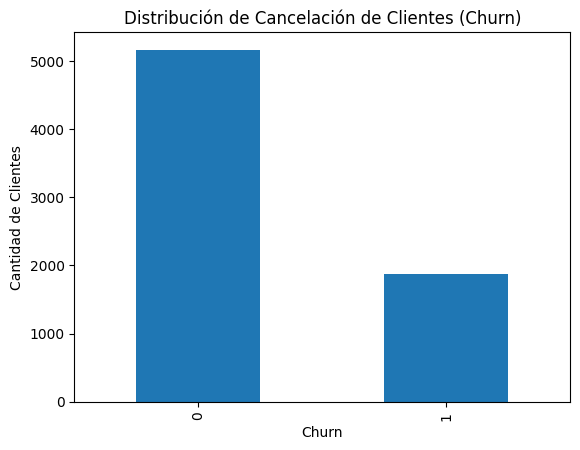

In [18]:
import matplotlib.pyplot as plt

df_encoded["Churn_bin"].value_counts().plot(
    kind="bar",
    title="Distribución de Cancelación de Clientes (Churn)"
)

plt.xlabel("Churn")
plt.ylabel("Cantidad de Clientes")
plt.show()

## 2.5 Balanceo de Clases (Opcional)

Después de analizar la proporción de cancelación, se observa que la variable objetivo Churn_bin presenta un desbalance entre sus clases.

* Clientes que no cancelan (0): 73.42%
* Clientes que cancelan (1): 26.58%

Este tipo de distribución es común en problemas de predicción de abandono de clientes, donde la mayoría de los usuarios tiende a permanecer en el servicio.

Un dataset desbalanceado puede afectar el desempeño de los modelos de clasificación, ya que estos podrían aprender a predecir con mayor frecuencia la clase mayoritaria. Sin embargo, en este caso el desbalance no es extremo, por lo que inicialmente se puede continuar con el modelado utilizando los datos originales.

En etapas posteriores del análisis, si fuera necesario, podrían aplicarse técnicas de balanceo como oversampling, undersampling o métodos como SMOTE para mejorar la capacidad predictiva del modelo.

## 2.6 Normalización o Estandarización

En algunos algoritmos de machine learning es necesario escalar las variables numéricas para evitar que aquellas con mayor magnitud influyan de forma desproporcionada en el modelo.

Las técnicas más comunes son:

* Normalización (Min-Max Scaling): transforma los valores a un rango entre 0 y 1.
* Estandarización (Standardization): centra los datos en una media de 0 y desviación estándar de 1.

Sin embargo, utilizaremos modelos basados en árboles de decisión que no requieren normalización, ya que realizan divisiones basadas en umbrales de las variables y no en distancias entre observaciones.

Dado que en este análisis se utilizarán árboles de decisión, no se aplicará normalización en esta etapa. No obstante, este proceso podría ser necesario si posteriormente se implementan algoritmos sensibles a la escala de los datos.

#**3. Correlación y Selección de Variables**

##3.1 Matriz de Correlación

Una vez que los datos han sido limpiados y transformados a formato numérico, es posible analizar la relación entre las variables del dataset. Para ello se utiliza una matriz de correlación, que permite medir el grado de relación lineal entre las diferentes variables.

La correlación se calcula mediante el coeficiente de correlación de Pearson, cuyos valores oscilan entre -1 y 1:
* 1 → correlación positiva perfecta
* 0 → no existe correlación
* -1 → correlación negativa perfecta

Este análisis permite identificar variables que pueden tener una mayor relación con la variable objetivo Churn_bin, lo que resulta útil para comprender mejor los factores asociados a la cancelación de clientes.

In [19]:
# Calcular matriz de correlación
matriz_correlacion = df_encoded.corr()

# Visualizar primeras filas
matriz_correlacion.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_bin,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
customer.SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.219874,0.150541,-0.001819,0.016957,-0.210550,0.008392,...,-0.182519,0.105445,-0.182519,0.119842,-0.046491,-0.116205,0.156258,-0.024359,0.171322,-0.152987
customer.tenure,0.015683,1.000000,0.246862,0.825880,0.246862,-0.354049,0.005285,0.381912,0.163386,0.007877,...,-0.037529,0.280264,-0.037529,0.285402,0.202338,0.563801,0.004823,0.232800,-0.210197,-0.232181
account.Charges.Monthly,0.219874,0.246862,1.000000,0.651065,1.000000,0.192858,-0.013779,0.097825,-0.112343,0.248033,...,-0.763191,0.629668,-0.763191,0.627235,0.004810,-0.073256,0.351930,0.030055,0.271117,-0.376568
account.Charges.Total,0.102411,0.825880,0.651065,1.000000,0.651065,-0.199484,0.000048,0.319072,0.064653,0.113008,...,-0.374878,0.515709,-0.374878,0.519867,0.170569,0.358036,0.157830,0.182663,-0.060436,-0.294708
Cuentas_Diarias,0.219874,0.246862,1.000000,0.651065,1.000000,0.192858,-0.013779,0.097825,-0.112343,0.248033,...,-0.763191,0.629668,-0.763191,0.627235,0.004810,-0.073256,0.351930,0.030055,0.271117,-0.376568


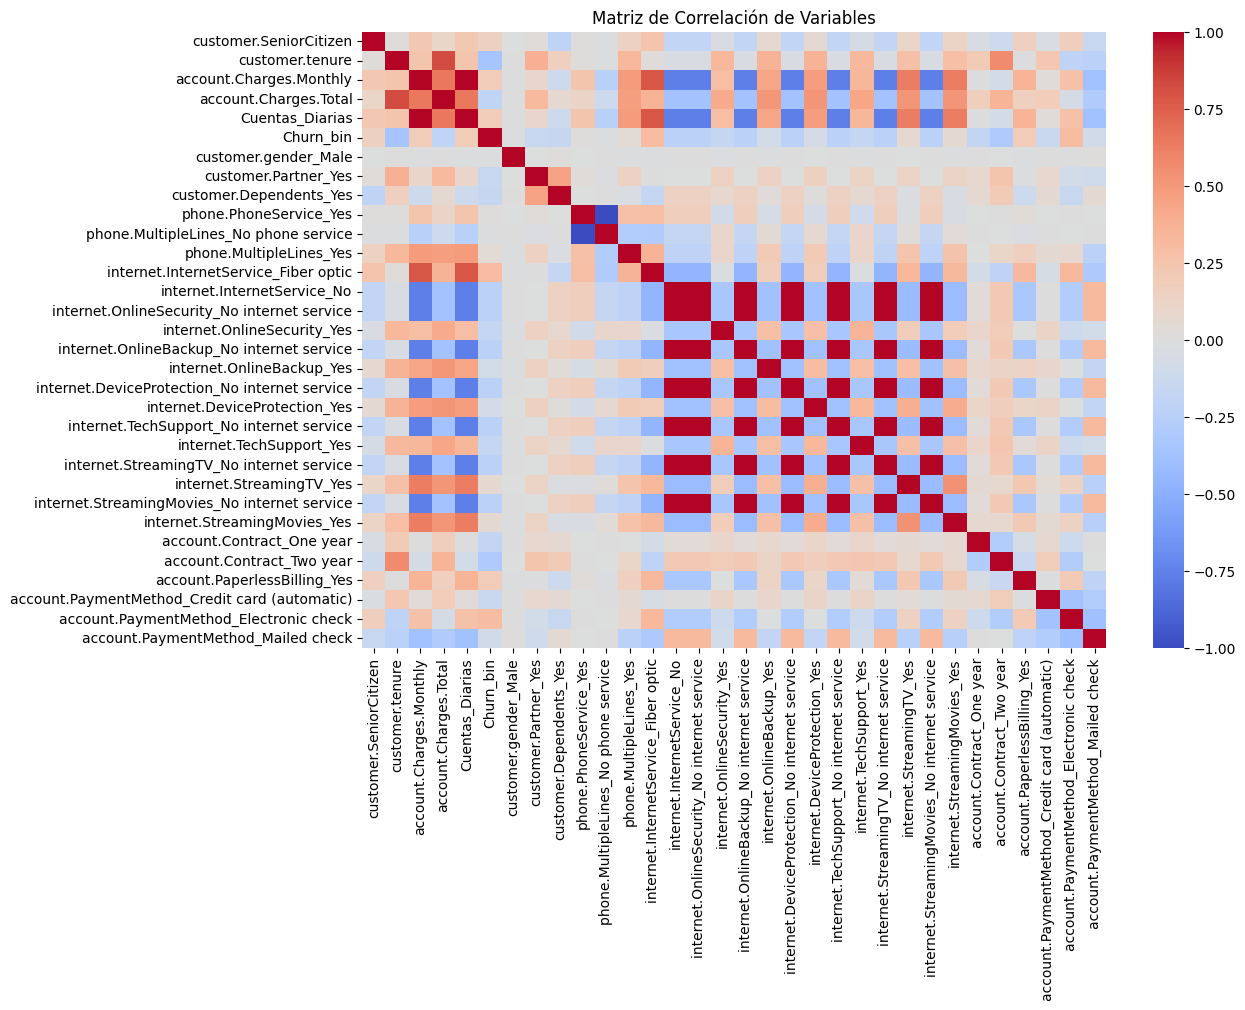

In [21]:
# Visialización de la matriz

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(matriz_correlacion, cmap="coolwarm")
plt.title("Matriz de Correlación de Variables")
plt.show()

**Interpretación**

La matriz de correlación permite identificar:

* Variables que presentan mayor relación con la cancelación de clientes (Churn_bin)

* Variables que podrían estar altamente correlacionadas entre sí, lo cual puede indicar redundancia en la información.

Este análisis constituye un paso preliminar para la selección de variables relevantes, que será explorado en las siguientes secciones del proyecto.

##3.2 Análisis Dirigido de Variables Relevantes

Para facilitar la interpretación de la matriz de correlación, se realiza un análisis dirigido enfocándose exclusivamente en la relación entre las variables predictoras y la variable objetivo Churn_bin.

Esto permite identificar qué características de los clientes presentan mayor asociación con la cancelación del servicio.

In [27]:
correlacion_con_churn = matriz_correlacion["Churn_bin"].sort_values(ascending=False)

correlacion_con_churn.head()

,Churn_bin
Churn_bin,1.000000
internet.InternetService_Fiber optic,0.307463
account.PaymentMethod_Electronic check,0.301455
Cuentas_Diarias,0.192858
account.Charges.Monthly,0.192858


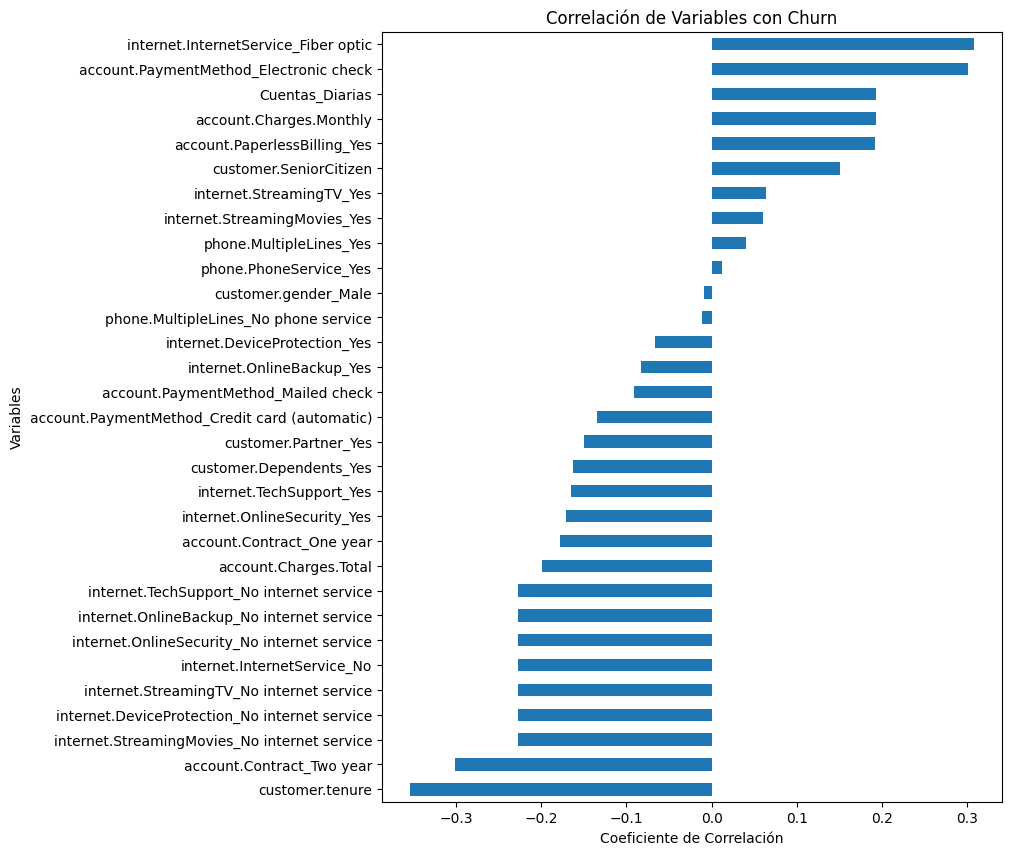

In [24]:
plt.figure(figsize=(8,10))

correlacion_con_churn.drop("Churn_bin").sort_values().plot(
    kind="barh"
)

plt.title("Correlación de Variables con Churn")
plt.xlabel("Coeficiente de Correlación")
plt.ylabel("Variables")

plt.show()

#**4. Modelado Predictivo**

##4.1 Separación de Datos

Para evaluar el rendimiento del modelo predictivo, el dataset se divide en dos subconjuntos: datos de entrenamiento y datos de prueba.

El conjunto de entrenamiento se utiliza para que el modelo aprenda los patrones presentes en los datos, mientras que el conjunto de prueba permite evaluar su capacidad de generalización sobre datos no vistos previamente.

En este caso se utiliza una división 80% para entrenamiento y 20% para prueba, lo que permite contar con una cantidad suficiente de datos para entrenar el modelo sin comprometer la evaluación.

In [32]:
#Separacion de las variables
X = df_encoded.drop("Churn_bin", axis=1)
y = df_encoded["Churn_bin"]

In [33]:
#Division del Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
#Verificacion de dimensiones

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 31)
X_test: (1407, 31)
y_train: (5625,)
y_test: (1407,)


In [35]:
#Verificación de proporcion
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn_bin
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn_bin
0    0.734186
1    0.265814
Name: proportion, dtype: float64


**Interpretación**

La división generó 5625 registros para entrenamiento y 1407 para prueba.
Cada conjunto contiene 31 variables predictoras.

Gracias al uso del parámetro stratify, la proporción de cancelación de clientes se mantiene consistente entre ambos conjuntos, lo que permite una evaluación más confiable del modelo.

##4.2 Entrenamiento de Modelos

En esta etapa se entrenan dos modelos de clasificación para predecir la cancelación de clientes. El objetivo es comparar el desempeño de diferentes enfoques de aprendizaje automático.

Se seleccionaron dos algoritmos con características distintas:
Regresión Logística, que es sensible a la escala de las variables y requiere normalización.

Árbol de Decisión, que no depende de la escala de los datos y puede entrenarse directamente con las variables originales.

Esta comparación permite analizar cómo influyen las características del algoritmo en el desempeño del modelo.

###Modelo 1: Regresión Logística

La Regresión Logística es un algoritmo de clasificación ampliamente utilizado que estima la probabilidad de que una observación pertenezca a una determinada clase.

Debido a que este modelo es sensible a la escala de las variables, se aplica estandarización utilizando StandardScaler. Este proceso transforma las variables para que tengan una media de 0 y desviación estándar de 1, evitando que variables con mayor magnitud influyan desproporcionadamente en el modelo.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression

modelo_logr = LogisticRegression(random_state=42, max_iter=1000)

modelo_logr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

###Modelo 2: Árbol de Decisión

El Árbol de Decisión es un algoritmo basado en reglas que divide los datos en diferentes ramas según condiciones aplicadas a las variables.

A diferencia de modelos como la regresión logística o KNN, los árboles de decisión no dependen de la escala de las variables, ya que las divisiones se realizan mediante comparaciones de valores y no mediante cálculos de distancia.

Por esta razón, no es necesario aplicar normalización antes de entrenar el modelo.

In [38]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

##4.3 Evaluación de Modelos

Una vez entrenados los modelos, es necesario evaluar su rendimiento utilizando diferentes métricas de clasificación. Estas métricas permiten analizar qué tan bien los modelos predicen la cancelación de clientes.

Las métricas utilizadas son:
* Exactitud (Accuracy): proporción de predicciones correctas.
* Precisión (Precision): proporción de predicciones positivas correctas.
* Recall: capacidad del modelo para identificar correctamente los casos positivos.
* F1-score: promedio armónico entre precisión y recall.
* Matriz de confusión: muestra la distribución de predicciones correctas e incorrectas.

In [39]:
# Predicciones Regresión Logistica
y_logr_pred = modelo_logr.predict(X_test_scaled)

# Predicciones Árbol de Decision
y_arbol_pred = modelo_arbol.predict(X_test)

In [42]:
#Calculo de metricas

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_logr_pred))
print("Precision:", precision_score(y_test, y_logr_pred))
print("Recall:", recall_score(y_test, y_logr_pred))
print("F1-score:", f1_score(y_test, y_logr_pred))

print("\nÁrbol de Decisión")
print("Accuracy:", accuracy_score(y_test, y_arbol_pred))
print("Precision:", precision_score(y_test, y_arbol_pred))
print("Recall:", recall_score(y_test, y_arbol_pred))
print("F1-score:", f1_score(y_test, y_arbol_pred))

Regresión Logística
Accuracy: 0.8009950248756219
Precision: 0.6556291390728477
Recall: 0.5294117647058824
F1-score: 0.5857988165680473

Árbol de Decisión
Accuracy: 0.7036247334754797
Precision: 0.44266666666666665
Recall: 0.44385026737967914
F1-score: 0.4432576769025367


In [44]:
#Matriz de confusion
from sklearn.metrics import confusion_matrix

print("Matriz de confusión - Regresión Logística")
print(confusion_matrix(y_test, y_logr_pred))

print("\nMatriz de confusión - Árbol de Decisión")
print(confusion_matrix(y_test, y_arbol_pred))

Matriz de confusión - Regresión Logística
[[929 104]
 [176 198]]

Matriz de confusión - Árbol de Decisión
[[824 209]
 [208 166]]


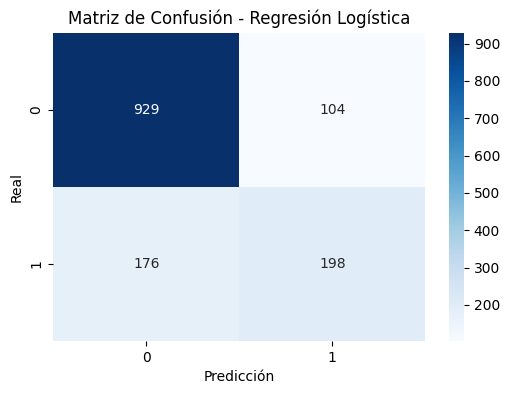

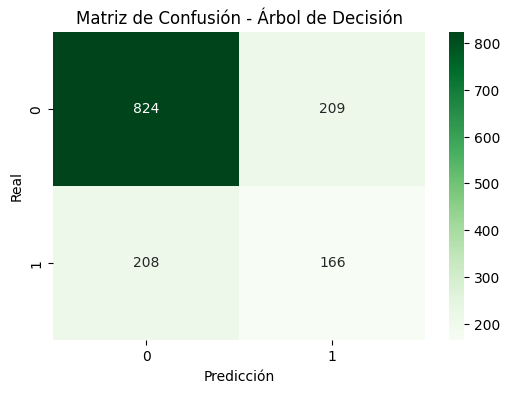

In [45]:
#Visualizacion de la Matriz de confusion

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_logr_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_arbol_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

##4.4 Comparación de Resultados

**Análisis Comparativo de Modelos**

Los resultados obtenidos muestran que la Regresión Logística presenta un mejor desempeño general en comparación con el modelo de Árbol de Decisión.

En términos de exactitud, la Regresión Logística alcanza aproximadamente 80%, mientras que el Árbol de Decisión obtiene cerca de 70%. Además, la Regresión Logística presenta mejores valores en precisión, recall y F1-score, lo que indica una mayor capacidad para identificar correctamente a los clientes que cancelan el servicio.

El análisis de las matrices de confusión muestra que la Regresión Logística logra detectar una mayor cantidad de clientes que efectivamente cancelan el servicio, mientras que el Árbol de Decisión presenta un mayor número de errores tanto en falsos positivos como en falsos negativos.

Esto sugiere que el modelo de Árbol de Decisión podría requerir ajustes en sus hiperparámetros, como la profundidad máxima del árbol (max_depth), para mejorar su capacidad predictiva.

En conclusión, para este conjunto de datos, la Regresión Logística ofrece un mejor equilibrio entre precisión y capacidad de detección del churn, por lo que resulta ser el modelo más adecuado entre los evaluados.

##4.5 Mejorando los resultados de Árbol de Decisión

In [46]:
#Buscando el maxdepth optimo

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = range(1, 21)

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

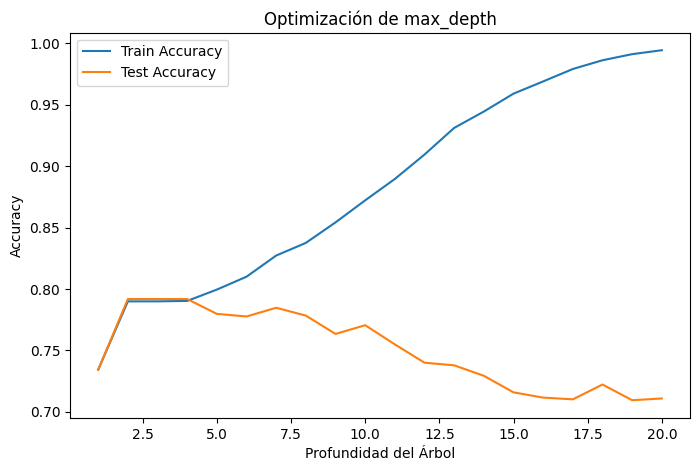

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(depths, train_scores, label="Train Accuracy")
plt.plot(depths, test_scores, label="Test Accuracy")

plt.xlabel("Profundidad del Árbol")
plt.ylabel("Accuracy")
plt.title("Optimización de max_depth")
plt.legend()

plt.show()

In [50]:
arbol_mejorado = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

arbol_mejorado.fit(X_train, y_train)

y_pred_tree_opt = best_tree.predict(X_test)

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree_opt))
print("Precision:", precision_score(y_test, y_pred_tree_opt))
print("Recall:", recall_score(y_test, y_pred_tree_opt))
print("F1-score:", f1_score(y_test, y_pred_tree_opt))

Accuracy: 0.7796730632551528
Precision: 0.5993788819875776
Recall: 0.516042780748663
F1-score: 0.5545977011494253


**Interpretación**

Para mejorar el desempeño del modelo de Árbol de Decisión, se realizó un ajuste del hiperparámetro max_depth, que controla la profundidad máxima del árbol. Al limitar la profundidad del modelo se logró reducir el sobreajuste y mejorar la capacidad de generalización.

Los resultados muestran una mejora significativa en todas las métricas evaluadas en comparación con el árbol inicial. Sin embargo, la Regresión Logística continúa presentando el mejor rendimiento global, con valores superiores en accuracy, precisión, recall y F1-score.

Esto sugiere que, para este conjunto de datos, un modelo lineal como la Regresión Logística logra capturar de forma más efectiva los patrones asociados a la cancelación de clientes.

#**5. Interpretación del Modelo**

##5.1 Importancia de Variables

Después de entrenar los modelos predictivos, es importante analizar qué variables influyen más en la predicción de cancelación de clientes. Este análisis permite comprender mejor los factores asociados al churn y proporciona información valiosa para la toma de decisiones.

En este caso, se analizan las variables más relevantes según los dos modelos utilizados: Regresión Logística y Árbol de Decisión.

###Importancia de variables en Regresión Logística


En la regresión logística, los coeficientes del modelo indican cómo cada variable influye en la probabilidad de cancelación. Un coeficiente positivo indica que la variable aumenta la probabilidad de churn, mientras que un coeficiente negativo indica que reduce dicha probabilidad.

In [54]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_logr.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes

,Variable,Coeficiente
11,internet.InternetService_Fiber optic,0.644955
3,account.Charges.Total,0.609028
22,internet.StreamingTV_Yes,0.240530
27,account.PaperlessBilling_Yes,0.181353
24,internet.StreamingMovies_Yes,0.170661
29,account.PaymentMethod_Electronic check,0.166748
10,phone.MultipleLines_Yes,0.159134
0,customer.SeniorCitizen,0.093651
18,internet.DeviceProtection_Yes,0.046981
9,phone.MultipleLines_No phone service,0.002321


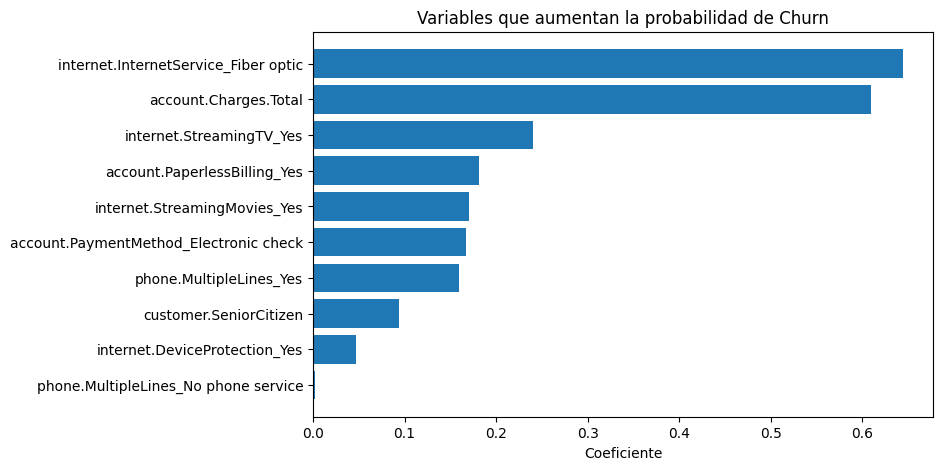

In [56]:
#Varaibles mas importantes

import matplotlib.pyplot as plt

top_variables = coeficientes.sort_values(by="Coeficiente", ascending=False).head(10)

plt.figure(figsize=(8,5))

plt.barh(top_variables["Variable"], top_variables["Coeficiente"])

plt.title("Variables que aumentan la probabilidad de Churn")
plt.xlabel("Coeficiente")

plt.gca().invert_yaxis()

plt.show()

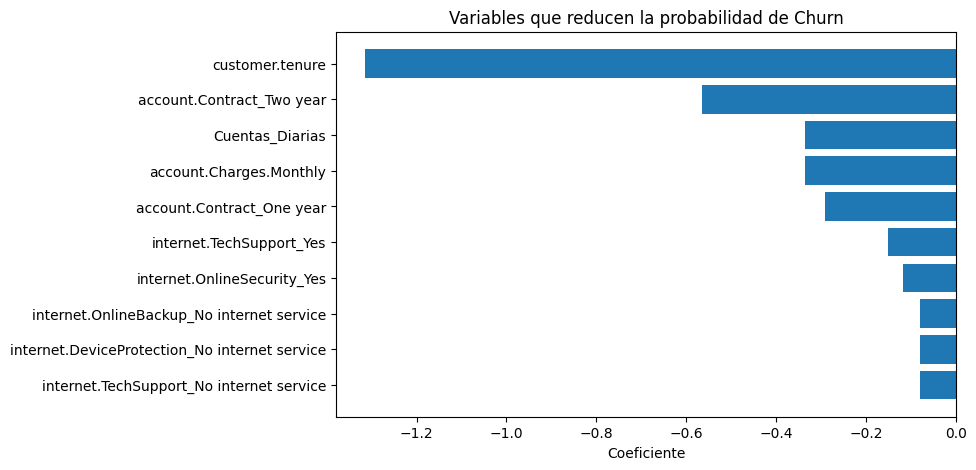

In [58]:
#Variables que reducen la probabiliada de Churn

bottom_variables = coeficientes.sort_values(by="Coeficiente").head(10)

plt.figure(figsize=(8,5))

plt.barh(bottom_variables["Variable"], bottom_variables["Coeficiente"])

plt.title("Variables que reducen la probabilidad de Churn")
plt.xlabel("Coeficiente")

plt.gca().invert_yaxis()

plt.show()

###Importancia de variables en Árbol de Decisión

Los árboles de decisión permiten calcular directamente la importancia de cada variable, basada en cuánto contribuye a reducir la impureza en las divisiones del árbol.

In [59]:
importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": best_tree.feature_importances_
})

importancia = importancia.sort_values(by="Importancia", ascending=False)

importancia

,Variable,Importancia
1,customer.tenure,0.442406
11,internet.InternetService_Fiber optic,0.344339
3,account.Charges.Total,0.047761
29,account.PaymentMethod_Electronic check,0.034862
15,internet.OnlineBackup_No internet service,0.030541
25,account.Contract_One year,0.025102
26,account.Contract_Two year,0.024253
2,account.Charges.Monthly,0.019342
0,customer.SeniorCitizen,0.009762
14,internet.OnlineSecurity_Yes,0.006537


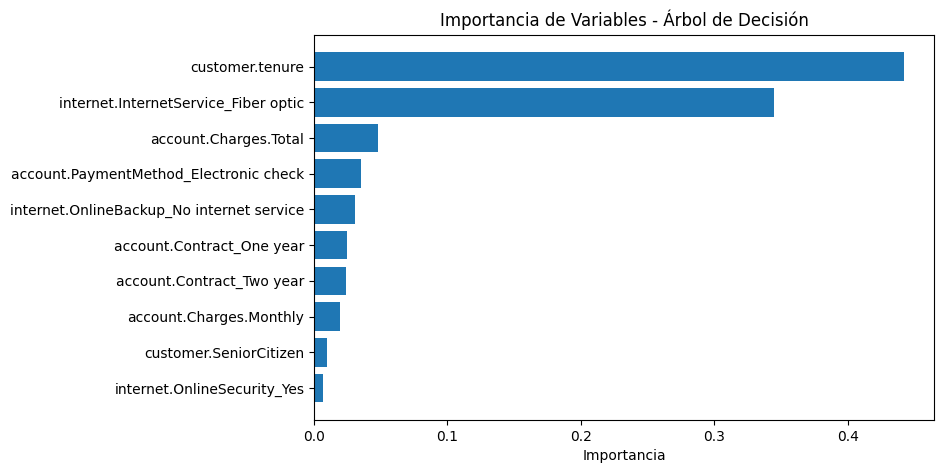

In [60]:
top_importancia = importancia.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_importancia["Variable"], top_importancia["Importancia"])

plt.title("Importancia de Variables - Árbol de Decisión")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()

##5.2 Variables más Influyentes en la Cancelación

Para identificar los factores más influyentes en la predicción de churn, se analizaron dos modelos distintos: una regresión logística y un árbol de decisión. Ambos modelos permiten evaluar la relevancia de las variables, aunque desde enfoques diferentes.

### Resultados de la Regresión Logística

La **Regresión logística** estima coeficientes que indican la dirección y magnitud de la relación entre cada variable y la probabilidad de cancelación. En este modelo, las variables con mayor impacto positivo fueron:

- **internet.InternetService_Fiber optic (0.64)**  
- **account.Charges.Total (0.61)**  
- **internet.StreamingTV_Yes (0.24)**  
- **account.PaperlessBilling_Yes (0.18)**  
- **internet.StreamingMovies_Yes (0.17)**  
- **account.PaymentMethod_Electronic check (0.17)**  

Estos coeficientes positivos indican que la presencia o aumento de estas variables está asociado con una mayor probabilidad de cancelación del servicio.

Por otro lado, algunas variables presentaron coeficientes negativos importantes, lo que sugiere una asociación con **menor probabilidad de churn**:

- **customer.tenure (-1.31)**  
- **account.Contract_Two year (-0.57)**  
- **account.Contract_One year (-0.29)**  
- **account.Charges.Monthly (-0.34)**  

Esto indica que los clientes con mayor antigüedad o con contratos de mayor duración tienden a permanecer en la empresa.

### Resultados del Árbol de Decisión

En el caso del árbol de decisión, la importancia de las variables se mide según cuánto contribuyen a reducir la impureza del modelo durante las divisiones del árbol. Las variables más influyentes fueron:

1. **customer.tenure (0.44)**  
2. **internet.InternetService_Fiber optic (0.34)**  
3. **account.Charges.Total (0.05)**  
4. **account.PaymentMethod_Electronic check (0.03)**  
5. **internet.OnlineBackup_No internet service (0.03)**  

Se observa que **customer.tenure** y **internet.InternetService_Fiber optic** aparecen como variables clave en ambos modelos, lo que refuerza su importancia en la explicación del churn. En contraste, varias variables presentan importancia cercana a cero en el árbol, lo que indica que no fueron utilizadas en las divisiones del modelo.

En conjunto, el análisis sugiere que **la antigüedad del cliente, el tipo de servicio de internet, el tipo de contrato y los cargos asociados al servicio** son los factores más relevantes para explicar la cancelación del servicio en el conjunto de datos analizado.

#**6. Informe final: análisis de cancelación de clientes (Churn)**

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes utilizando técnicas de aprendizaje automático. Para ello se entrenaron distintos modelos predictivos y se analizaron las variables más relevantes en cada uno, con el fin de comprender los patrones asociados al churn y proponer estrategias de retención.

## 6.1 Factores que influyen en la cancelación de clientes

A partir del análisis de regresión logística y del árbol de decisión, se identificaron varias variables con alta influencia en la cancelación del servicio.

Uno de los factores más importantes es **la antigüedad del cliente (customer.tenure)**. Esta variable aparece como la más influyente en ambos modelos, mostrando que los clientes con menor tiempo en la empresa tienen una mayor probabilidad de cancelar el servicio. Por el contrario, a medida que aumenta la antigüedad, la probabilidad de churn disminuye significativamente.

Otro factor relevante es el **tipo de servicio de internet**, particularmente **Fiber optic**. Este tipo de servicio muestra una asociación positiva con la cancelación, lo que podría indicar que los clientes con este servicio tienen expectativas más altas o experimentan problemas de costo o calidad.

También se observa que las variables relacionadas con **los costos del servicio** tienen un impacto importante. En particular:

- **account.Charges.Total**
- **account.Charges.Monthly**

Los clientes con cargos elevados pueden presentar una mayor sensibilidad al precio, lo que incrementa el riesgo de cancelación.

El **tipo de contrato** también influye de forma significativa. Los clientes con contratos de **un año o dos años** presentan una menor probabilidad de churn en comparación con aquellos que poseen contratos mensuales. Esto sugiere que los compromisos a largo plazo ayudan a estabilizar la base de clientes.

Finalmente, el **método de pago**, especialmente **Electronic check**, aparece como un factor asociado a una mayor probabilidad de cancelación. Esto podría indicar que ciertos perfiles de clientes o hábitos de pago están relacionados con mayor rotación.

En conjunto, los factores más influyentes identificados fueron:

- Antigüedad del cliente (tenure)
- Tipo de servicio de internet
- Tipo de contrato
- Cargos mensuales y totales
- Método de pago

## 6.2 Comparación del rendimiento de los modelos

Se utilizaron dos enfoques principales para el análisis: **regresión logística** y **árbol de decisión**.

La **regresión logística** permitió interpretar la relación entre cada variable y la probabilidad de cancelación mediante los coeficientes del modelo. Este enfoque es útil para comprender la dirección del efecto de cada variable, es decir, si aumenta o disminuye la probabilidad de churn.

Por otro lado, el **árbol de decisión** permitió identificar qué variables son más relevantes al momento de realizar las divisiones que explican el comportamiento de los clientes. Este modelo destacó principalmente la importancia de **customer.tenure** y **internet.InternetService_Fiber optic**, lo que coincide con los resultados observados en la regresión.

La coincidencia de variables relevantes en ambos modelos fortalece la confiabilidad del análisis, ya que distintos métodos identificaron patrones similares en los datos.

## 6.3 Estrategias de retención de clientes

A partir de los factores identificados, es posible proponer algunas estrategias orientadas a reducir la cancelación de clientes.

**1. Programas de fidelización para clientes nuevos**  
Dado que los clientes con menor antigüedad presentan mayor probabilidad de cancelación, se podrían implementar programas de fidelización durante los primeros meses del servicio, como descuentos iniciales, beneficios exclusivos o seguimiento personalizado.

**2. Incentivar contratos de largo plazo**  
Los resultados muestran que los contratos de uno o dos años reducen significativamente el churn. Por lo tanto, la empresa podría ofrecer incentivos o descuentos a los clientes que opten por contratos de mayor duración.

**3. Revisar la percepción de valor del servicio de fibra óptica**  
Dado que el servicio de fibra óptica aparece asociado a mayor cancelación, sería recomendable analizar posibles problemas de satisfacción, precio o calidad del servicio en este segmento de clientes.

**4. Optimización de precios y planes de servicio**  
Los cargos mensuales influyen en la cancelación, por lo que podría ser útil revisar la estructura de precios, ofrecer planes más flexibles o generar paquetes de servicios con mayor valor percibido.

**5. Análisis de comportamiento según método de pago**  
El método de pago Electronic check muestra una mayor asociación con churn. La empresa podría incentivar métodos de pago automáticos que mejoren la retención y reduzcan la rotación.

## 6.4 Conclusiones

El análisis permitió identificar patrones relevantes asociados a la cancelación de clientes. Entre los factores más importantes se encuentran la antigüedad del cliente, el tipo de servicio contratado, el tipo de contrato y los cargos asociados al servicio.

Los modelos utilizados mostraron resultados consistentes en la identificación de estas variables clave, lo que refuerza la validez del análisis. A partir de estos hallazgos, es posible diseñar estrategias de retención enfocadas en mejorar la fidelización de clientes, optimizar la oferta de servicios y reducir la tasa de cancelación.

En conclusión, el uso de técnicas de análisis de datos y aprendizaje automático permite comprender mejor el comportamiento de los clientes y apoyar la toma de decisiones estratégicas orientadas a mejorar la retención y la satisfacción del cliente.